## 前置任務 - DAv2輸出 metric depth
Depth Anything V2, Github: https://github.com/DepthAnything/Depth-Anything-V2

按需修改參數：

```
python metric_depth/run.py \
  --encoder vitl \
  --load-from metric_depth/checkpoints/depth_anything_v2_metric_hypersim_vitl.pth \
  --max-depth 20 \
  --img-path "data/cold_inputs" \
  --outdir "data/cold_depth_metric_vitl_980" \
  --input-size 980 \
  --save-numpy --pred-only --grayscale
```

# Cold Storage Fog Synthesis via Atmospheric Scattering Model (ASM)

## 路徑解釋
先準備好depth圖格式npy data/cold_depth_metric_vitl_980，霧圖將生成到 data/cold_fog_synthesized

## Physical Model

**Koschmieder's Law** (McCartney 1976, Narasimhan & Nayar 2002):

$$I(x) = J(x) \cdot t(x) + A \cdot (1 - t(x))$$

$$t(x) = \exp(-\beta \cdot d(x))$$

- **I(x)**: Foggy image (output)
- **J(x)**: Clear image (input)
- **t(x)**: Transmission map
- **A**: Atmospheric light (white-ish for cold storage)
- **β**: Scattering coefficient (controls fog density)
- **d(x)**: Metric depth (meters)

## Parameter Design

| Level | β | Visibility | t @ 4m |
|-------|---|------------|--------|
| light | 0.06 | ~65m | ~0.79 |
| medium | 0.20 | ~20m | ~0.45 |
| heavy | 0.50 | ~8m | ~0.14 |

**A** = [0.95, 0.95, 0.95] (cold storage white lighting)


## 論文參考
1. Narasimhan & Nayar, 2002
- 題名：Vision and the Atmosphere
- 出處：IJCV
- DOI 連結：https://doi.org/10.1023/A:1016328200723
- 可讀版本（作者頁 PDF）：https://cave.cs.columbia.edu/old/publications/pdfs/Narasimhan_IJCV02.pdf

2. McCartney, 1976（這是大氣光學書籍，不是 conference/journal 論文）
- 題名：Optics of the Atmosphere: Scattering by Molecules and Particles
- 參考連結（ADS）：https://ui.adsabs.harvard.edu/abs/1976nyjw.book.....M/abstract
- 參考連結（Archive）：https://archive.org/details/opticsofatmosphe0000mcca

Koschmieder’s Law 原始經典常追溯到 Koschmieder 1924。
bibliographic 入口（可用於定位原文資訊）：https://cir.nii.ac.jp/crid/1573668924092647424?lang=en

## 霧生成參數設定

In [7]:
import os
import glob
import random
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

# Paths
DATA_ROOT = "data"
INPUT_DIR = os.path.join(DATA_ROOT, "cold_inputs")
DEPTH_DIR = os.path.join(DATA_ROOT, "cold_depth_metric_vitl_980")
OUTPUT_DIR = os.path.join(DATA_ROOT, "cold_fog_synthesized")

# ASM parameters: beta (scattering coeff), A (atmospheric light)
BETA_CONFIG = {"light": 0.06, "medium": 0.20, "heavy": 0.50}
A = np.array([0.95, 0.95, 0.95], dtype=np.float32)

# Matplotlib: English labels in Times New Roman
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10

In [8]:
def list_input_images(input_dir=INPUT_DIR):
    """List valid input images with mixed extensions."""
    patterns = ["*.jpg", "*.png", "*.JPG", "*.PNG"]
    files = []
    for pattern in patterns:
        files.extend(Path(input_dir).glob(pattern))
    files = [str(p) for p in files if not p.name.startswith(".")]
    return sorted(files)


def collect_pairs(input_dir=INPUT_DIR, depth_dir=DEPTH_DIR):
    """Collect (clear_path, depth_path) pairs by basename matching."""
    pairs = []
    for clear_path in list_input_images(input_dir):
        base = os.path.splitext(os.path.basename(clear_path))[0]
        depth_path = os.path.join(depth_dir, f"{base}_raw_depth_meter.npy")
        if os.path.exists(depth_path):
            pairs.append((clear_path, depth_path))
    return pairs


def sanitize_depth(depth_map):
    """Ensure depth is finite and non-negative."""
    depth_map = np.nan_to_num(depth_map, nan=0.0, posinf=0.0, neginf=0.0)
    return np.clip(depth_map, 0.0, None).astype(np.float32)


# Narasimhan & Nayar, 2002, IJCV（電腦視覺中經典大氣散射模型）
# DOI: https://doi.org/10.1023/A:1016328200723
# （物理根源）Koschmieder 定律（經典可見度/衰減模型）
def synthesize_fog(clear_img, depth_map, beta, A):
    """
    ASM: I(x) = J(x)*t(x) + A*(1-t(x)), t = exp(-beta*d)
    Args:
        clear_img: (H,W,3) uint8 BGR
        depth_map: (H,W) float32, meters
        beta: float
        A: (3,) float32
    Returns:
        foggy: (H,W,3) uint8 BGR
    """
    h, w = clear_img.shape[:2]
    depth_map = sanitize_depth(depth_map)
    if depth_map.shape[:2] != (h, w):
        depth_map = cv2.resize(depth_map, (w, h), interpolation=cv2.INTER_LINEAR)

    J = clear_img.astype(np.float32) / 255.0
    t = np.exp(-beta * depth_map)
    t = np.expand_dims(t, axis=-1)

    I = J * t + A * (1.0 - t)
    I = np.clip(I * 255.0, 0.0, 255.0).astype(np.uint8)
    return I


# Sakaridis, Dai, Van Gool, IJCV 2018
# Semantic Foggy Scene Understanding with Synthetic Data
# Link: https://doi.org/10.1007/s11263-018-1072-8
# Project: https://people.ee.ethz.ch/~csakarid/SFSU_synthetic/
def get_transmission(depth_map, beta):
    """Get transmission map t = exp(-beta*d)."""
    depth_map = sanitize_depth(depth_map)
    return np.exp(-beta * depth_map)

In [9]:
pairs = collect_pairs()
print(f"Found {len(pairs)} valid pairs for visualization")

Found 400 valid pairs for visualization


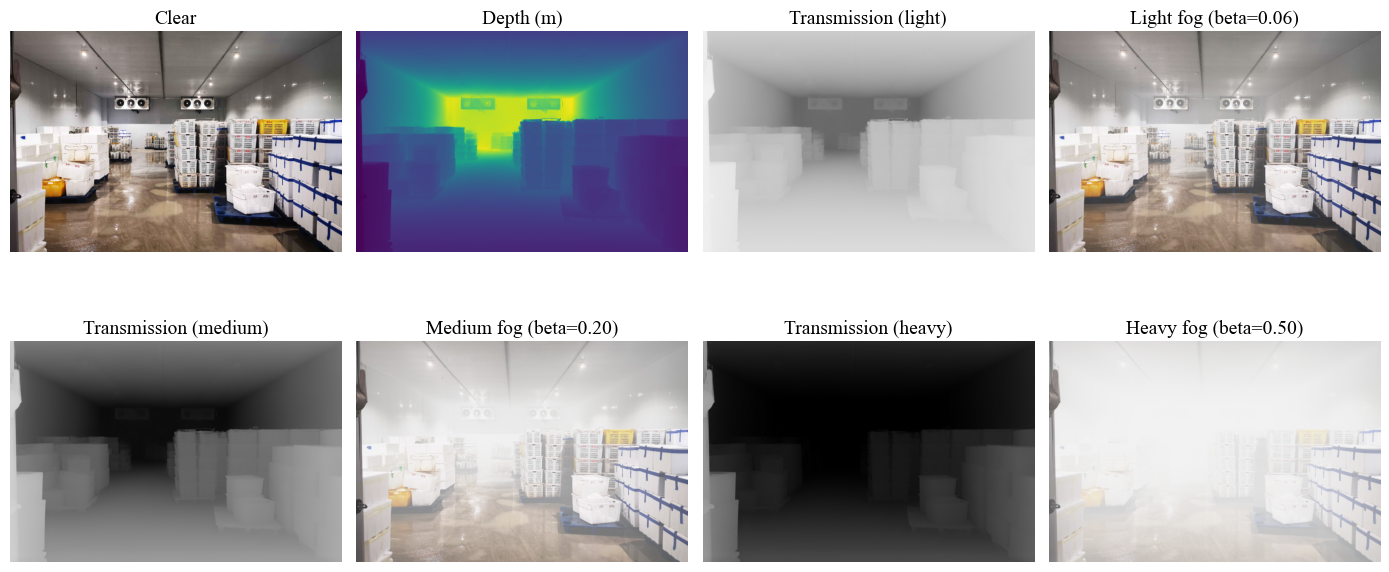

In [17]:
def visualize_single(clear_path, depth_path, save_path=None):
    """Visualize: clear | depth | transmission | light/medium/heavy fog."""
    clear = cv2.imread(clear_path)
    if clear is None:
        raise ValueError(f"Failed to read image: {clear_path}")
    clear_rgb = cv2.cvtColor(clear, cv2.COLOR_BGR2RGB)

    depth = np.load(depth_path)
    depth = sanitize_depth(depth)
    if depth.shape[:2] != clear.shape[:2]:
        depth = cv2.resize(depth, (clear.shape[1], clear.shape[0]), interpolation=cv2.INTER_LINEAR)

    fog_light = synthesize_fog(clear, depth, BETA_CONFIG["light"], A)
    fog_medium = synthesize_fog(clear, depth, BETA_CONFIG["medium"], A)
    fog_heavy = synthesize_fog(clear, depth, BETA_CONFIG["heavy"], A)
    t_light = get_transmission(depth, BETA_CONFIG["light"])
    t_medium = get_transmission(depth, BETA_CONFIG["medium"])
    t_heavy = get_transmission(depth, BETA_CONFIG["heavy"])

    plt.rcParams["axes.titlesize"] = 14
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    axes[0, 0].imshow(clear_rgb)
    axes[0, 0].set_title("Clear")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(depth, cmap="viridis")
    axes[0, 1].set_title("Depth (m)")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(t_light, cmap="gray", vmin=0, vmax=1)
    axes[0, 2].set_title("Transmission (light)")
    axes[0, 2].axis("off")

    axes[0, 3].imshow(cv2.cvtColor(fog_light, cv2.COLOR_BGR2RGB))
    axes[0, 3].set_title("Light fog (beta=0.06)")
    axes[0, 3].axis("off")

    axes[1, 0].imshow(t_medium, cmap="gray", vmin=0, vmax=1)
    axes[1, 0].set_title("Transmission (medium)")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(cv2.cvtColor(fog_medium, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title("Medium fog (beta=0.20)")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(t_heavy, cmap="gray", vmin=0, vmax=1)
    axes[1, 2].set_title("Transmission (heavy)")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(cv2.cvtColor(fog_heavy, cv2.COLOR_BGR2RGB))
    axes[1, 3].set_title("Heavy fog (beta=0.50)")
    axes[1, 3].axis("off")

    fig.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

if pairs:
    visualize_single(*pairs[0])
else:
    print("No valid image-depth pair found.")

## 生成冷庫霧圖

In [4]:
pairs = collect_pairs()
print(f"Found {len(pairs)} image-depth pairs")

for level in BETA_CONFIG:
    os.makedirs(os.path.join(OUTPUT_DIR, level), exist_ok=True)

success = 0
failed = 0

for clear_path, depth_path in tqdm(pairs, desc="Batch fog synthesis"):
    base = os.path.splitext(os.path.basename(clear_path))[0]
    clear = cv2.imread(clear_path)

    if clear is None:
        failed += 1
        print(f"[Skip] failed to read image: {clear_path}")
        continue

    try:
        depth = np.load(depth_path)
        depth = sanitize_depth(depth)
    except Exception as exc:
        failed += 1
        print(f"[Skip] failed to load depth {depth_path}: {exc}")
        continue

    ok = True
    for level, beta in BETA_CONFIG.items():
        try:
            fog = synthesize_fog(clear, depth, beta, A)
            out_path = os.path.join(OUTPUT_DIR, level, f"{base}.png")
            cv2.imwrite(out_path, fog)
        except Exception as exc:
            ok = False
            print(f"[Skip] synthesis failed for {base} ({level}): {exc}")
            break

    if ok:
        success += 1
    else:
        failed += 1

print(f"Batch done. Success: {success}, Failed: {failed}")

Found 400 image-depth pairs


Batch fog synthesis: 100%|██████████| 400/400 [04:07<00:00,  1.62it/s]

Batch done. Success: 400, Failed: 0


## 抽樣檢查效果

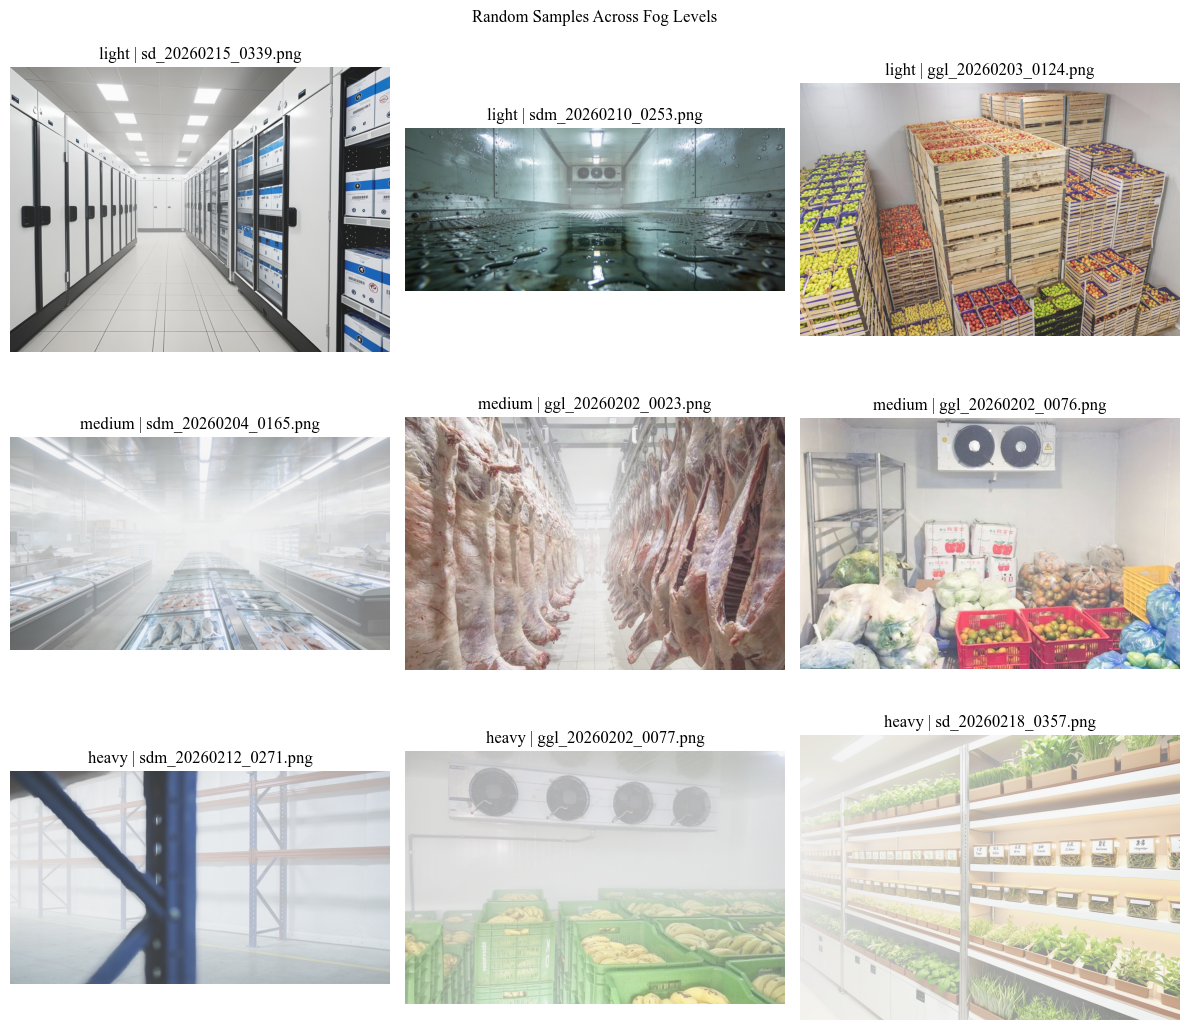


Statistics:
  light   : count=400, sampled=100, mean=157.79, std=46.60
  medium  : count=400, sampled=100, mean=187.62, std=35.21
  heavy   : count=400, sampled=100, mean=215.35, std=21.78


In [2]:
# Self-contained cell: can run directly after notebook restart.
import os
import glob
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Fallback config if previous cells have not been executed.
if "DATA_ROOT" not in globals():
    DATA_ROOT = "data"
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = os.path.join(DATA_ROOT, "cold_fog_synthesized")
if "BETA_CONFIG" not in globals():
    BETA_CONFIG = {"light": 0.06, "medium": 0.20, "heavy": 0.50}

# Ensure English plotting style and Times New Roman.
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 10


def _show_random_samples_all_levels(num_samples_per_level=3):
    """Show random samples for light / medium / heavy in one figure."""
    levels = list(BETA_CONFIG.keys())
    selected = {}

    for level in levels:
        files = sorted(glob.glob(os.path.join(OUTPUT_DIR, level, "*.png")))
        if not files:
            selected[level] = []
            continue
        k = min(num_samples_per_level, len(files))
        selected[level] = random.sample(files, k)

    if all(len(v) == 0 for v in selected.values()):
        print("No synthesized images found. Please run batch synthesis first.")
        return

    cols = max(len(v) for v in selected.values())
    cols = max(cols, 1)
    rows = len(levels)

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.6 * rows))
    axes = np.atleast_2d(axes)

    for r, level in enumerate(levels):
        row_files = selected[level]
        for c in range(cols):
            ax = axes[r, c]
            if c < len(row_files):
                p = row_files[c]
                img = cv2.imread(p)
                if img is None:
                    ax.set_title(f"{level}: unreadable")
                    ax.axis("off")
                    continue
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                ax.set_title(f"{level} | {os.path.basename(p)}")
                ax.axis("off")
            else:
                ax.axis("off")

    plt.suptitle("Random Samples Across Fog Levels", fontsize=12)
    plt.tight_layout()
    plt.show()


def quality_check_and_stats(per_level_max=100, num_samples_per_level=3):
    """Show samples for all levels and print basic statistics."""
    _show_random_samples_all_levels(num_samples_per_level=num_samples_per_level)

    stats = []
    for level in BETA_CONFIG:
        files = sorted(glob.glob(os.path.join(OUTPUT_DIR, level, "*.png")))
        sample_files = files[:per_level_max]
        means, stds = [], []

        for f in sample_files:
            img = cv2.imread(f)
            if img is None:
                continue
            means.append(float(img.mean()))
            stds.append(float(img.std()))

        stats.append(
            {
                "level": level,
                "count": len(files),
                "sampled": len(sample_files),
                "mean": float(np.mean(means)) if means else 0.0,
                "std": float(np.mean(stds)) if stds else 0.0,
            }
        )

    print("\nStatistics:")
    for s in stats:
        print(
            f"  {s['level']:8s}: count={s['count']}, sampled={s['sampled']}, "
            f"mean={s['mean']:.2f}, std={s['std']:.2f}"
        )


quality_check_and_stats(per_level_max=100, num_samples_per_level=3)